In [ ]:
print("hello")

hello


hello


In [ ]:
import os 
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode

load_dotenv() 
if os.getenv("GROQ_API_KEY"):
    print("the key is present")
else:
    print("the key is not present")

llm=ChatGroq(
    api_key=os.getenv("GROQ_API_KEY"),
    temperature=0,
    model="openai/gpt-oss-120b"
)

#workflow within a workflow








@tool 
def calculator(expression: str) -> str:
    """Calculate a basic mathematical expression."""

    try:
        result = eval(
            expression,
            {"__builtins__": {}},
            {}
        )

        return str(result)

    except Exception:
        return "Invalid expression."

@tool
def add(a: float, b:float)-> float:
    """Add two numbers."""
    return a + b



llm_with_tool=llm.bind_tools([calculator,add])

class State(TypedDict):
    messages:  Annotated[list[BaseMessage], add_messages]

def llm_node(state: State):
    response=llm_with_tool.invoke(  state["messages"])
    return {"messages":[response]}
def approval_node(state: State):
    last_message = state["messages"][-1]

    tool_call = last_message.tool_calls[0]

    approval = interrupt({
        "question": "Approve this tool call?",
        "tool": tool_call["name"],
        "arguments": tool_call["args"],
    })

    if approval != "yes":
        raise ValueError("Tool call rejected by human.")

    return {}


def route_after_llm(state: State):
    last_message = state["messages"][-1]

    if last_message.tool_calls:
        return "approval"

    return END


# 7. Tool execution node
tool_node = ToolNode([add, calculator])

builder=StateGraph(State)

builder.add_node("llm", llm_node)
builder.add_node("approval", approval_node)
builder.add_node("tools", tool_node)

builder.add_edge(START, "llm")

builder.add_conditional_edges(
    "llm",
    route_after_llm,
    {
        "approval": "approval",
        END: END,
    },
)

builder.add_edge("approval", "tools")
builder.add_edge("tools", "llm")


# 9. Add memory
memory = MemorySaver()

graph = builder.compile(checkpointer=memory)


# 10. Use one conversation/thread
config = {
    "configurable": {
        "thread_id": "simple-demo"
    }
}


result = graph.invoke(
    {
        "messages": [
            HumanMessage(content="What is 10 plus 20?")
        ]
    },
    config=config,
)

print("First result:")
print(result)

print("\nInterrupt information:")
print(result.get("__interrupt__"))

print(result)


approval = input("\nType yes to approve the tool call: ")

result = graph.invoke(
    Command(resume=approval),
    config=config,
)

print("\nFinal answer:")
print(result["messages"][-1].content)

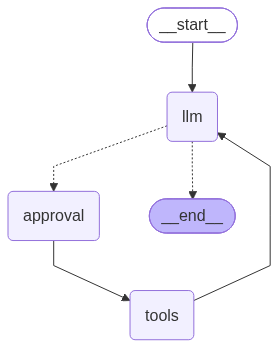

In [11]:
from IPython.display import Image, display

newGrap=builder.compile();

display(Image(newGrap.get_graph().draw_mermaid_png()))